In [4]:
from lib.LaneATT import LaneATTInference
import matplotlib.pyplot as plt
from pathlib import Path
from lib.config import Config
import cv2
import torch

import warnings
warnings.filterwarnings('ignore')
    
    # print(evaluation)

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor


class LaneATTInference():
    """LaneATT lane inference: model loading, per-frame eval with confidence
    hysteresis, and ego-lane extraction with the width-prior fallback.
    video.py owns the video loop and calls into this class."""

    def __init__(self, model_archiecture, model_path, device = torch.device("cuda:0"),
                 conf_threshold = 0.5, nms_thres = 50, nms_topk = 4,
                 keep_threshold = 0.3, match_tolerance = 0.05):
        self.device = device
        self.to_tensor = ToTensor()
        self.model_archiecture = model_archiecture
        self.load_model(model_path)
        # Per-y-row EMA of ego-lane width in pixels, learned while both edges are
        # visible. Width varies with y (perspective), so it must be per-row, not
        # a single scalar. Used to synthesize a missing edge from the visible one.
        self.lane_width_by_y = {}
        self.conf_threshold = conf_threshold
        self.nms_thres = nms_thres
        self.nms_topk = nms_topk
        # Hysteresis: conf_threshold acquires a NEW lane; a lane matched (by
        # bottom-row x, within match_tolerance in normalized coords) to one
        # accepted in the previous frame survives down to keep_threshold.
        self.keep_threshold = keep_threshold
        self.match_tolerance = match_tolerance
        self.prev_lane_xs = []
        


    def load_model(self, wieghts):
        # `wieghts` is a checkpoint path; the bare architecture comes in separately
        # via model_archiecture and gets the checkpoint's state_dict loaded into it.
        self.model_path = wieghts
        state_dict = torch.load(
            wieghts,
            map_location='cpu'
        )['model']
        self.model_archiecture.load_state_dict(state_dict)
        self.model_archiecture.to(self.device)
        self.model_archiecture.eval()

    def update_paramaters(self, conf_threshold, nms_thres, nms_topk):
        self.conf_threshold = conf_threshold
        self.nms_thres = nms_thres
        self.nms_topk = nms_topk

    def reset_video_state(self):
        # Per-video state: width prior and hysteresis memory must not leak
        # between videos (different roads, different lane widths).
        self.lane_width_by_y = {}
        self.prev_lane_xs = []

    def frame_eval(self, frame):
        frame = cv2.resize(frame, (640, 360))
        
        frame = self.to_tensor(frame)
        frame = frame.unsqueeze(0).to(self.device)
        # print(f"frame output: {frame.shape}")
        # NMS runs at the LOW keep_threshold so borderline lanes reach the
        # hysteresis filter below instead of being discarded inside the model.
        output = self.model_archiecture(frame, conf_threshold=self.keep_threshold, nms_thres=self.nms_thres, nms_topk=self.nms_topk)
        lanes = self.model_archiecture.decode(output, as_lanes=True)[0]
        # print(f"frame eval: {lanes[0]}")
        return lanes
        return self.filter_lanes_hysteresis(lanes)


    def filter_lanes(self, lanes):
        for lane in lanes:
            pts = lane.points
            
            
            
            print(f"pts: {pts}")
        return []
    
    
    def filter_lanes_hysteresis(self, lanes):
        # Two-threshold acceptance: a new lane must score >= conf_threshold, but
        # one whose botto
        #m-row x matches a lane accepted in the previous frame
        # survives down to keep_threshold. Stops real lanes from blinking in/out
        # when their score hovers around a single threshold; weak false positives
        # never cross the acquire bar, so they are never tracked.
        # print(f"filter_lanes_hysteresis: {lanes}")
        # print(f"length: {len(lanes)}")
        accepted, accepted_xs = [], []
        for lane in lanes:
            print(f"filter_lanes_hysteresis getting lane: {lane}")
            print(type(lane))
            conf = float(lane.metadata['conf'])
            pts = lane.points   # normalized (x, y) in [0, 1]
            x_bottom = float(pts[np.argmax(pts[:, 1]), 0])
            tracked = any(abs(x_bottom - px) < self.match_tolerance for px in self.prev_lane_xs)
            if conf >= self.conf_threshold or (tracked and conf >= self.keep_threshold):
                accepted.append(lane)
                accepted_xs.append(x_bottom)
        self.prev_lane_xs = accepted_xs
        print(f"accepted: {accepted}")
        return accepted

    def lanes_to_px(self, lanes, w, h):
        out = []
        for lane in lanes:
            pts = lane.points.copy().astype(float)
            pts[:, 0] *= w          # Lane.points are normalized (x, y) in [0, 1]
            pts[:, 1] *= h
            out.append(pts.round().astype(int))
        return out

    def split_left_right(self,lanes,x_mid):
        left = []
        right = []
        for lane in lanes:
            count_left = 0
            count_right = 0
            for cord in lane:
                if cord[0] < x_mid:
                    count_left += 1
                else:
                    count_right += 1
            if count_left > count_right:
                left.append(lane)
            else:
                right.append(lane)

        return left, right
    
    def closest_left_right(self, left, right, x_mid):
        pass
        
        

    def find_two_smallest(self, arr):
        # Initialize both variables to infinity
        smallest = second_smallest = float('inf')
        small_name = ""
        for num in arr.values():
            if num < smallest:
                second_smallest = smallest

                smallest = num
            elif num < second_smallest:
                # Change to 'elif num < second_smallest and num != smallest:'
                # if you strictly want the second smallest *distinct* element.
                second_smallest = num

        return [smallest, second_smallest]

         
        

    def get_ego_lanes(self, img_w, predictions):

        mid_point_x = img_w / 2


        left_candidates = []   # (x_bottom, lane_index), x_bottom < mid
        right_candidates = []  # (x_bottom, lane_index), x_bottom >= mid
        for i, lane in enumerate(predictions):
            bottom_idx = np.argmax(lane[:, 1])  # largest y = nearest the car
            x_bottom = lane[bottom_idx, 0]
            if x_bottom < mid_point_x:
                left_candidates.append((x_bottom, i))
            else:
                right_candidates.append((x_bottom, i))

        if not left_candidates and not right_candidates:
            return None, None, None, None

        # Closest lane to center on each side: largest x on the left, smallest x on the right.
        left_points = right_points = None
        if left_candidates:
            left_points = predictions[max(left_candidates, key=lambda t: t[0])[1]]
        if right_candidates:
            right_points = predictions[min(right_candidates, key=lambda t: t[0])[1]]

        # `synthesized` names the edge ('left'/'right') that was inferred from the
        # width prior instead of detected, or None when both edges are real.
        synthesized = None
        if left_points is not None and right_points is not None:
            # Both edges visible: learn the per-row lane width (EMA, alpha=0.2).
            left_by_y = {int(y): x for x, y in left_points}
            right_by_y = {int(y): x for x, y in right_points}
            for y in set(left_by_y) & set(right_by_y):
                w = right_by_y[y] - left_by_y[y]
                if w <= 0:
                    continue
                old = self.lane_width_by_y.get(y)
                self.lane_width_by_y[y] = w if old is None else 0.8 * old + 0.2 * w
        elif self.lane_width_by_y:
            # One edge missing: synthesize it by offsetting the visible edge by
            # the learned width, at rows where both a point and a width exist.
            visible = left_points if left_points is not None else right_points
            sign = 1 if left_points is not None else -1   # left visible -> right = x + w
            synth = [[x + sign * self.lane_width_by_y[int(y)], y]
                     for x, y in visible if int(y) in self.lane_width_by_y]
            if len(synth) < 2:
                return None, None, None, None   # too little prior overlap to trust
            synth = np.array(synth).round().astype(int)
            if left_points is not None:
                right_points, synthesized = synth, 'right'
            else:
                left_points, synthesized = synth, 'left'
        else:
            return None, None, None, None

        # Midpoints between the two ego lanes, one per shared y-row.
        left_by_y = {int(y): x for x, y in left_points}
        right_by_y = {int(y): x for x, y in right_points}
        shared_ys = sorted(set(left_by_y) & set(right_by_y))
        mid_points = np.array([[(left_by_y[y] + right_by_y[y]) / 2, y] for y in shared_ys], dtype=int)

        return left_points, right_points, mid_points, synthesized

    def show_frame(self, image, predictions):
        left_points, right_points, mid_points, synthesized = self.get_ego_lanes(image.shape[1], predictions)

        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        if left_points is None:
            print("Could not find lanes on both sides of center; skipping midpoint.")
        else:
            print(f"left_points: {left_points}")
            print(f"right_points: {right_points}")
            plt.scatter(left_points[:, 0], left_points[:, 1], c='lime', s=10, label='left ego lane')
            plt.scatter(right_points[:, 0], right_points[:, 1], c='cyan', s=10, label='right ego lane')
            if len(mid_points) > 0:
                plt.scatter(mid_points[:, 0], mid_points[:, 1], c='red', s=10, label='midpoint')
            plt.legend(loc='upper right')

        return left_points, right_points, mid_points
    
    def get_ego_lanes2(self, img_w, predictions):
        mid_point_x = img_w / 2
        print(mid_point_x)
        print(len(predictions))
        for i, j in enumerate(predictions):
            print(f"Index {i}: {len(j)}")  
        print(predictions[0])
    



In [6]:
import matplotlib.pyplot as plt
from pathlib import Path
from lib.config import Config
import cv2
import torch

import warnings
warnings.filterwarnings('ignore')
    

image = "video_input/IMG_3046.jpeg"
models = [("experiments/LaneATTresnet34Aug2/config.yaml", "experiments/LaneATTresnet34Aug2/models/model_0020.pt", ""), ("experiments/LaneATTresnet50Aug2/config.yaml", "experiments/LaneATTresnet50Aug2/models/model_0030.pt", "")
          ]
models = [("experiments/LaneATTresnet34Aug2/config.yaml", "experiments/LaneATTresnet34Aug2/models/model_0020.pt", "")]
# models = [("experiments/LaneATTresnet50Aug2/config.yaml", "experiments/LaneATTresnet50Aug2/models/model_0030.pt", "")]
# models = [("experiments/LaneATTresnet50Aug2/config.yaml", "experiments/LaneATTresnet50Aug2/models/model_0024.pt", "")]

video = "video_input/IMG_5105.mp4"

cap = cv2.VideoCapture(video)
folder_name = "jupyter_video"
out_stream = Path(folder_name)

out_stream.mkdir(parents=True, exist_ok=True)

print(folder_name)


final_video_path = out_stream / "output.mp4"


jupyter_video


len: 1


KeyboardInterrupt: 

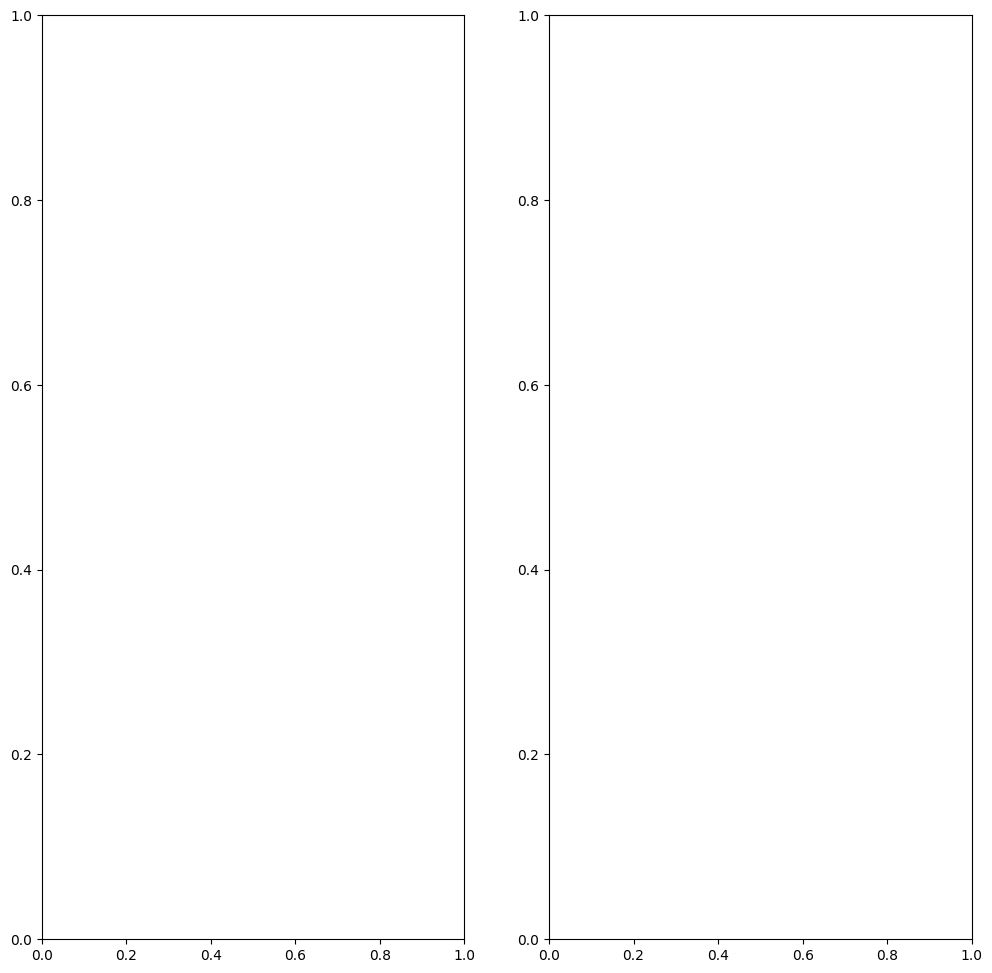

In [7]:
# from lib.LaneATT import LaneATTInference
import matplotlib.pyplot as plt
from pathlib import Path
from lib.config import Config
import cv2
import torch

import warnings
warnings.filterwarnings('ignore')
    

image = "video_input/IMG_3046.jpeg"
models = [("experiments/LaneATTresnet34Aug2/config.yaml", "experiments/LaneATTresnet34Aug2/models/model_0020.pt", ""), ("experiments/LaneATTresnet50Aug2/config.yaml", "experiments/LaneATTresnet50Aug2/models/model_0030.pt", "")
          ]
models = [("experiments/LaneATTresnet34Aug2/config.yaml", "experiments/LaneATTresnet34Aug2/models/model_0020.pt", "")]
# models = [("experiments/LaneATTresnet50Aug2/config.yaml", "experiments/LaneATTresnet50Aug2/models/model_0030.pt", "")]
# models = [("experiments/LaneATTresnet50Aug2/config.yaml", "experiments/LaneATTresnet50Aug2/models/model_0024.pt", "")]

print(f'len: {len(models)}')

fig, axes = plt.subplots(
    nrows=len(models),
    ncols=2,
    figsize=(12, 12)
)
axes = np.atleast_2d(axes)  



# def split_left_right(lanes):
#     """lane dicts -> (left, right), ordered by bottom-row x position.

#     laneatt_decode keeps at most 2 lanes by default (nms_topk=2), which for
#     ego-lane detection are the left and right boundary. Missing side(s) come
#     back as None rather than guessing.
#     """
#     if not lanes:
#         return None, None
#     scored = sorted(lanes, key=self._bottom_x)
#     if len(scored) == 1:
#         return (scored[0], None) if self._bottom_x(scored[0]) < 0.5 else (None, scored[0])
#     return scored[0], scored[-1]



for i, (config_path, path_model, _) in enumerate(models):
    # print(type(i))
    # print(f"Running inference for model: {path_model}")
    cfg = Config(config_path)
    name = Path(path_model).stem
    model_name = Path(path_model).parent.parent.name
    # output_folder = Path(output_root) / model_name / name

    model = LaneATTInference(cfg.get_model(), path_model, device=torch.device("cpu"), conf_threshold=0., nms_thres=50, nms_topk=5, keep_threshold=0.3, match_tolerance=0.05)
    new_image = cv2.imread(image)
    evaluation = model.frame_eval(new_image)
    # print(f"evaluation: {evaluation}")
    height, width, channels = new_image.shape
    pts_all = model.lanes_to_px(evaluation, width, height)
    # print(f'pts_all: {pts_all}')
    # print(f"Length pts_all: {len(pts_all)}")
    
    # for i in pts_all:
    #     print(f"each length: {len(i)}")

        
    
    
    # for pts in pts_all:
    #     for p0, p1 in zip(pts[:-1], pts[1:]):
    #         cv2.line(new_image, tuple(p0), tuple(p1), (0, 255, 0), 3)
            
            
    new_image_rgb = cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)
    axes[i,0].imshow(new_image_rgb)
    axes[i,0].set_title(Path(path_model).parent.parent.name)
    axes[i,0].axis("off")
    
    # print(f"shape: {width}, pts_all: {pts_all}")
    # model.get_ego_lanes2(width, pts_all)
    
    mid_x = width // 2
    left, right = model.split_left_right(pts_all, mid_x)
    
    highest_top = height
    
    for left_lanes in left:
        print(type(left_lanes), left_lanes)
        top = tuple(left_lanes[0])
        bottom  = tuple(left_lanes[-1])
        
        if highest_top > top[1]:
            print(f"highest top: {top[1]}")
            highest_top = int(top[1])
        
     
        # print(f"bottom: {bottom},  type: {type(bottom)}")
        # print(f"Top: {top},  type: {type(top)}")
        cv2.line(new_image, bottom, top, (255,0,0), 15)

    for right_lanes in right:
        print(type(right_lanes), right_lanes)
        top = tuple(right_lanes[0])
        bottom = tuple(right_lanes[-1])
        if highest_top > top[1]:
            print(f"highest top: {top[1]}")
            highest_top = int(top[1])
        # print(f"bottom: {bottom}, type: {type(bottom)}")
        # print(f"Top: {top}, type: {type(top)}")
        cv2.line(new_image, bottom, top, (0,0,255), 15)
        
        
    print(f'highest y: {highest_top}, height: {height}')
    bottom_mid = (mid_x, height)
    top_mid = (mid_x, highest_top)
    print(f"line from {bottom_mid} to {top_mid}")   
    
    cv2.line(new_image, bottom_mid, top_mid, (0,255,0), 15)

        
    
    
    print(f"There are {len(left)} left lanes detected.")
    print(f"There are {len(right)} right lanes detected")
        
    
    # left_points, right_points, mid_points, synthesized = model.get_ego_lanes(new_image.shape[1], pts_all)

    # print(f"mid_points:{mid_points}")
    # print(f"left_points: {left_points}")
    # print(f"right_points: {right_points}")
    # if left_points is not None and right_points is not None and mid_points is not None:
    #     left_color = (255, 0, 0)    # orange / magenta
    #     right_color =  (0, 0, 255)  # orange / cyan
    #     mid_color = (0, 255, 0)    # green
    #     for p0, p1 in zip(left_points[:-1], left_points[1:]):
    #         cv2.line(new_image, tuple(p0), tuple(p1), left_color, 15)
    #     for p0, p1 in zip(right_points[:-1], right_points[1:]):
    #         cv2.line(new_image, tuple(p0), tuple(p1), right_color, 15)
    #     for p0, p1 in zip(mid_points[:-1], mid_points[1:]):
    #         cv2.line(new_image, tuple(p0), tuple(p1), mid_color, 15)
    
    new_image_rgb = cv2.cvtColor(new_image, cv2.COLOR_BGR2RGB)
    axes[i,1].imshow(new_image_rgb)
    axes[i,1].set_title(Path(path_model).parent.parent.name)
    axes[i,1].axis("off")
        

plt.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import time

import cv2
import numpy as np
import torch
from lib.config import Config

# Run the LaneATTInference class-definition cell above first.
video = Path("video_input/IMG_5105.mp4")
config_path = "experiments/LaneATTresnet34Aug2/config.yaml"
path_model = "experiments/LaneATTresnet34Aug2/models/model_0020.pt"
final_video_path = Path("jupyter_video/output3.mp4")
final_video_path.parent.mkdir(parents=True, exist_ok=True)

cfg = Config(config_path)
model = LaneATTInference(
    cfg.get_model(), path_model, device=torch.device("cpu"),
    conf_threshold=0.9, nms_thres=50, nms_topk=3,
    keep_threshold=0.3, match_tolerance=0.05,
)
model.reset_video_state()
# frame_eval currently returns all decoded lanes at keep_threshold=0.3;
# the notebook's hysteresis filter is bypassed by its early return.

cap = cv2.VideoCapture(str(video))
writer = None
frame_count = 0
started = time.monotonic()
try:
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if not np.isfinite(fps) or fps <= 0:
        raise RuntimeError(f"Invalid source FPS: {fps}")
    ok, frame = cap.read()
    if not ok:
        raise RuntimeError(f"Cannot decode the first frame: {video}")
    height, width = frame.shape[:2]
    writer = cv2.VideoWriter(
        str(final_video_path), cv2.VideoWriter_fourcc(*"mp4v"),
        fps, (2 * width, height),
    )
    if not writer.isOpened():
        raise RuntimeError(f"Cannot create video: {final_video_path}")
    print(f"Writing {2 * width} x {height} at {fps:g} FPS; {total_frames} source frames", flush=True)

    i = 0 
    maximum = 500
    with torch.inference_mode():
        while i < maximum:
            i += 1
            annotated = frame.copy()  # Keep the original left panel untouched.
            lanes = model.frame_eval(frame)
            pts_all = model.lanes_to_px(lanes, width, height)
            left, right = model.split_left_right(pts_all, width // 2)
            highest_top = height
            for group, color in ((left, (255, 0, 0)), (right, (0, 0, 255))):
                for points in group:
                    if len(points) < 2:
                        continue
                    highest_top = min(highest_top, int(points[:, 1].min()))
                    # Follow every predicted point, including curved lanes.
                    cv2.polylines(
                        annotated, [points.astype(np.int32).reshape(-1, 1, 2)],
                        False, color, 5, cv2.LINE_AA,
                    )
            if highest_top < height:
                # Image-center reference from the image cell; not an ego centerline.
                cv2.line(annotated, (width // 2, height - 1),
                         (width // 2, max(0, highest_top)), (0, 255, 0), 5)
            writer.write(np.hstack((frame, annotated)))
            frame_count += 1
            if frame_count == 1 or frame_count % 100 == 0:
                elapsed = time.monotonic() - started
                print(f"{frame_count}/{total_frames} frames ({frame_count / elapsed:.1f} processed/sec)", flush=True)
            ok, frame = cap.read()
finally:
    cap.release()
    if writer is not None:
        writer.release()

if total_frames > 0 and frame_count != total_frames:
    raise RuntimeError(f"Decoded {frame_count} frames; expected {total_frames}")
print(f"Saved {frame_count} frames to {final_video_path.resolve()}", flush=True)

# Preserve the source audio without re-encoding either stream.
# import subprocess

# audio_video_path = final_video_path.with_name(final_video_path.stem + "_with_audio.mp4")
# subprocess.run([
#     "ffmpeg", "-v", "error", "-y", "-i", str(final_video_path),
#     "-i", str(video), "-map", "0:v:0", "-map", "1:a:0?",
#     "-c", "copy", "-movflags", "+faststart", str(audio_video_path),
# ], check=True)
# audio_video_path.replace(final_video_path)
# print(f"Final video with source audio: {final_video_path.resolve()}", flush=True)


Writing 3840 x 1080 at 59.97 FPS; 7441 source frames
1/7441 frames (4.6 processed/sec)
100/7441 frames (8.8 processed/sec)
200/7441 frames (9.0 processed/sec)
300/7441 frames (9.1 processed/sec)
400/7441 frames (9.2 processed/sec)
500/7441 frames (9.3 processed/sec)


RuntimeError: Decoded 500 frames; expected 7441

In [5]:

import math
import re
import torch
import cv2
import time as time
import logging
from pathlib import Path

from lib.LaneATT import LaneATTInference
from lib.lanenet_infer import LaneNetInference
from lib.yolo import YoloInference
from lib.depth import DepthInference
from lib.angle import Angle
from PIL import Image
import numpy as np
import sys

class VideoInference():
    """Hub of the pipeline: owns the video loop, run folders, logging and drawing.
    model_type picks the lane model: "laneATT" -> LaneATT.py (LaneATTInference),
    "laneNet" -> lanenet_infer.py (LaneNetInference); object detection in
    yolo.py (YoloInference); parameters flow from here into those."""

    def __init__(self, model_type = "laneATT", model_archiecture = None, model_path = None, hnet_path = None, video_path = None, output_folder = None, view = True, frame_limit = 10000000000, device = torch.device("cuda:0"), conf_threshold = 0.5,  nms_thres = 50, nms_topk = 4, keep_threshold = 0.3, match_tolerance = 0.05, yolo_path = None, yolo_conf = 0.5, yolo_iou = 0.15):

        self.video_path = video_path

        if output_folder != None:
            output_path = Path(output_folder)
            output_path.mkdir(parents=True, exist_ok=True)
        self.output_folder = output_folder
        self.frame_limit = frame_limit
        self.view = view

        self.device = device

        # model_type picks the lane model: "laneNet" uses model_path (+ hnet_path),
        # "laneATT" uses model_archiecture + model_path.
        self.model_type = model_type
        self.laneatt = None
        self.lanenet = None
        
        self.nms_topk = nms_topk
        self.nms_thres = nms_thres
        self.keep_threshold = keep_threshold
        self.match_tolerance = match_tolerance
        self.yolo_iou = yolo_iou
        self.model_archiecture = model_archiecture
        self.model_path = model_path
        self.device = device 
        self.conf_threshold = conf_threshold
        
        self.yolo_path = yolo_path
        self.yolo_conf = yolo_conf
        self.yolo_iou = yolo_iou
        # if model_type == "laneNet":
        #     self.lanenet = LaneNetInference(model_path, hnet_path=hnet_path, device=device)

        self.laneatt = None
        # yolo_path=None -> YoloInference falls back to its lib-relative default weights.
        self.yolo = None
        
        self.update_laneATT()
        self.update_yolo()
        # Monocular relative depth (Depth-Anything-V2); picks cuda/cpu itself.
        # self.depth = DepthInference()
        # Steering + lead-vehicle layer over get_ego_lanes()/YOLO (laneATT path only;
        # the laneNet branch doesn't produce get_ego_lanes()-shaped midpoints).
        self.angle = Angle(vehicle_class_id=1)

        self.logger = logging.getLogger("VideoInference")
        self.logger.setLevel(logging.DEBUG)
        self.logger.addHandler(logging.StreamHandler())
        
        
    def update_laneATT(self):
        self.laneatt = LaneATTInference(self.model_archiecture,  self.model_path, device=self.device,
                                            conf_threshold=self.conf_threshold, nms_thres=self.nms_thres,
                                            nms_topk=self.nms_topk, keep_threshold=self.keep_threshold,
                                            match_tolerance=self.match_tolerance)
    def update_yolo(self):
        self.yolo = YoloInference(self.yolo_path, conf_threshold=self.yolo_conf, iou_threshold=self.yolo_iou,device=self.device)
        
    
    def update_nms_thres(self, nms_thres):
        self.nms_thres = nms_thres
        
        
    def update_nms_topk(self, nms_topk):
        self.nms_topk = nms_topk
    def update_keep_threshold(self, keep_threshold):
        self.keep_threshold = keep_threshold
    def update_match_tolerance(self, match_tolerance):
         self.match_tolerance = match_tolerance
    def update_yolo_iou(self, yolo_iou):
        self.yolo_iou = yolo_iou
        
    # def update_paramaters(self, conf_threshold, nms_thres, nms_topk):
    #     self.laneatt.update_paramaters(conf_threshold, nms_thres, nms_topk)

    def set_video_path(self, video_path):
        self.video_path = video_path
    def set_output_folder(self, output_path):
        self.output_folder = output_path
    def set_frame(self, frame):
        self.frame = frame
    def set_model(self, model_archiecture, model_path):
        # Swap in a LaneATT checkpoint and make LaneATT the active lane model.
        if self.laneatt is None:
            self.laneatt = LaneATTInference(model_archiecture, model_path, device=self.device)
        else:
            self.laneatt.model_archiecture = model_archiecture
            self.laneatt.load_model(model_path)
        self.model_type = "laneATT"

    def set_lanenet(self, model_path, hnet_path=None):
        # Load LaneNet (+ optional H-Net) and makepath it the active lane model.
        self.lanenet = LaneNetInference(model_path, hnet_path=hnet_path, device=self.device)
        self.model_type = "laneNet"

    def speed_eval(self, speed):
        # First Base Speed on if edges are found 
    
        return

    def video_eval(self):
        if self.video_path is None or not Path(self.video_path).exists():
            raise FileNotFoundError(f"Video path does not exist: {self.video_path}")
        print(f"Video Selected: {self.video_path}")
        cap = cv2.VideoCapture(self.video_path)
        out_stream = None
        folder_path = "frame_output"
        if (self.output_folder != None):
            # <output_folder>/<video_stem>/run<K>/ where K = 1 + highest existing run
            # number for THIS video (a global folder count collided across videos).
            video_folder = Path(self.output_folder) / Path(self.video_path).stem
            video_folder.mkdir(parents=True, exist_ok=True)
            existing_runs = [int(m.group(1)) for d in video_folder.iterdir()
                             if d.is_dir() and (m := re.fullmatch(r'run(\d+)', d.name))]
            folder_path = video_folder / f"run{max(existing_runs, default=0) + 1}"
            folder_path.mkdir(parents=True, exist_ok=True)
            final_video_path = folder_path / "output.mp4"
            log_path = folder_path / "run.log"
            # Drop the FileHandler from a prior video_eval() call so each video's log
            # lines don't get duplicated into the next run's log.
            for h in list(self.logger.handlers):
                if isinstance(h, logging.FileHandler):
                    self.logger.removeHandler(h)
            fh = logging.FileHandler(log_path)
            fh.setFormatter(logging.Formatter(
                '%(asctime)s,%(msecs)03d %(name)s %(levelname)s %(message)s',
                datefmt='%Y-%m-%d %H:%M:%S'))
            self.logger.addHandler(fh)
            self.logger.info(f"video: {self.video_path}")
            # if self.model_type == "laneNet":
            #     self.logger.info(f"model checkpoint: {self.lanenet.model_path} "
            #                      f"(hnet: {self.lanenet.hnet_path})")
            #     self.logger.info(f"params: yolo_conf={self.yolo.conf_threshold}, "
            #                      f"yolo_iou={self.yolo.iou_threshold}, "
            #                      f"frame_limit={self.frame_limit}")
            # else:
            #     self.logger.info(f"model checkpoint: {self.laneatt.model_path}")
            #     self.logger.info(f"params: conf_threshold={self.laneatt.conf_threshold}, "
            #                      f"nms_thres={self.laneatt.nms_thres}, nms_topk={self.laneatt.nms_topk}, "
            #                      f"keep_threshold={self.laneatt.keep_threshold}, "
            #                      f"match_tolerance={self.laneatt.match_tolerance}, "
            #                      f"yolo_conf={self.yolo.conf_threshold}, yolo_iou={self.yolo.iou_threshold}, "
            #                      f"frame_limit={self.frame_limit}")
            #     self.logger.info(f"angle params: hfov={self.angle.assumed_hfov_deg}, "
            #                      f"stanley_gain={self.angle.stanley_gain}, "
            #                      f"nominal_speed={self.angle.nominal_speed}, "
            #                      f"smoothing_alpha={self.angle.smoothing_alpha}, "
            #                      f"hold_decay={self.angle.hold_decay}, "
            #                      f"max_extrapolation_px={self.angle.max_extrapolation_px}, "
            #                      f"vehicle_class_id={self.angle.vehicle_class_id}, "
            #                      f"lane_width_m={self.angle.lane_width_m}")
            # self.logger.info(f"depth model: {self.depth.checkpoint} (device: {self.depth.device})")
            fourcc = cv2.VideoWriter_fourcc(*'mp4v')
            print(f"Output Located: {final_video_path}")
            out_stream = cv2.VideoWriter(str(final_video_path), fourcc, 30.0, (int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) * 2, int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))))
        i = 0

        fps = cap.get(cv2.CAP_PROP_FPS)
        self.logger.info(f'Video Frame rate: {str(fps)}')
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        self.logger.info(f"Total Frames: {total_frames}")
        duration_seconds = total_frames / fps if fps > 0 else 0
        self.logger.info(f"Video Duration: {duration_seconds}")

        if self.frame_limit > total_frames:
            local_frame_local = total_frames
        else:
            local_frame_local = self.frame_limit

        use_lanenet = self.model_type == "laneNet"
        lane_label = "LaneNet" if use_lanenet else "LaneATT"
        self.logger.info(f"devices: {lane_label} {self.device}, "
                         f"YOLO {self.yolo.model.device}")
        if not use_lanenet:
            self.laneatt.reset_video_state()
            self.angle.reset_video_state()
        synth_frames = 0     # frames where one edge came from the width prior
        no_ego_frames = 0    # frames with no usable ego-lane pair
        no_steer_frames = 0  # frames with no steering (even the held value expired)
        lead_frames = 0      # frames with a lead vehicle (CIPV) selected
        lane_time = 0.0      # cumulative lane-model inference seconds
        yolo_time = 0.0      # cumulative YOLO inference seconds
        depth_time = 0.0     # cumulative depth-model inference seconds

        t1 = time.time()
        
        
        frame_location = Path(folder_path) / Path("frames")
        frame_location.mkdir(parents=True, exist_ok=True)
        print(frame_location)

        while i < local_frame_local:
            ret, frame = cap.read()
            
            # if i == 2: 
            #     image_name = "frame_1.jpg"
            #     ok = cv2.imwrite(str(frame_location / image_name), frame)
            #     print(f"Saved {image_name}: {ok}")
            
            if not ret:
                break

            t = time.perf_counter()
            evaluation = self.laneatt.frame_eval(frame)
            
            if i == 2: 
                image_name = "frame_2.jpg"
                ok = cv2.imwrite(str(frame_location / image_name), frame)
                print(f"Saved {image_name}: {ok}")
            lane_time += time.perf_counter() - t

            # YOLO sees the raw frame, before any lane drawing lands on it.
            t = time.perf_counter()
            yolo_results = self.yolo.infer(frame)
            yolo_time += time.perf_counter() - t

            # Depth also runs on the raw frame (relative depth, unused downstream yet).
            # t = time.perf_counter()
            # depth_results = self.depth.infer(frame)
            # depth_time += time.perf_counter() - t

            if self.view:
                # if use_lanenet:
                #     frame = self.lanenet.draw(frame, evaluation)
                # else:
                #     pts_all = self.laneatt.lanes_to_px(evaluation, frame.shape[1], frame.shape[0])
                #     for pts in pts_all:
                #         for p0, p1 in zip(pts[:-1], pts[1:]):
                #             cv2.line(frame, tuple(p0), tuple(p1), (0, 255, 0), 3)

                #     # Colors are BGR (frame stays BGR end-to-end, see out_stream.write below).
                #     # A synthesized (width-prior) edge is drawn ORANGE instead of its
                #     # normal color so real vs inferred geometry is obvious in the video.
                #     left_points, right_points, mid_points, synthesized = self.laneatt.get_ego_lanes(frame.shape[1], pts_all)

                #     if left_points is not None:
                #         left_color = (0, 165, 255) if synthesized == 'left' else (255, 0, 255)    # orange / magenta
                #         right_color = (0, 165, 255) if synthesized == 'right' else (255, 255, 0)  # orange / cyan
                #         for p0, p1 in zip(left_points[:-1], left_points[1:]):
                #             cv2.line(frame, tuple(p0), tuple(p1), left_color, 4)
                #         for p0, p1 in zip(right_points[:-1], right_points[1:]):
                #             cv2.line(frame, tuple(p0), tuple(p1), right_color, 4)
                #         for x, y in mid_points:
                #             cv2.circle(frame, (int(x), int(y)), 4, (0, 0, 255), -1)   # red: midpoint
                #         synth_frames += synthesized is not None
                #     else:
                #         no_ego_frames += 1
                pts_all = self.laneatt.lanes_to_px(evaluation, frame.shape[1], frame.shape[0])
                for pts in pts_all:
                    for p0, p1 in zip(pts[:-1], pts[1:]):
                        cv2.line(frame, tuple(p0), tuple(p1), (0, 255, 0), 3)

                # Colors are BGR (frame stays BGR end-to-end, see out_stream.write below).
                # A synthesized (width-prior) edge is drawn ORANGE instead of its
                # normal color so real vs inferred geometry is obvious in the video.
                left_points, right_points, mid_points, synthesized = self.laneatt.get_ego_lanes(frame.shape[1], pts_all)

                
                print(f"left_points: {type(left_points)}: {left_points}")
                print(f"right_points: {type(right_points)}: {right_points}")
                print(f"mid_points: {type(mid_points)}: {mid_points}")
                
                if left_points is not None and right_points is not None and mid_points is not None:
                    left_color = (0, 165, 255) if synthesized == 'left' else (255, 0, 255)    # orange / magenta
                    right_color = (0, 165, 255) if synthesized == 'right' else (255, 255, 0)  # orange / cyan
                    for p0, p1 in zip(left_points[:-1], left_points[1:]):
                        cv2.line(frame, tuple(p0), tuple(p1), left_color, 4)
                    for p0, p1 in zip(right_points[:-1], right_points[1:]):
                        cv2.line(frame, tuple(p0), tuple(p1), right_color, 4)
                    for x, y in mid_points:
                        cv2.circle(frame, (int(x), int(y)), 4, (0, 0, 255), -1)   # red: midpoint
                    synth_frames += synthesized is not None
                else:
                    no_ego_frames += 1
                    
                # if i == 2: 
                #     image_name = "frame_3.jpg"
                #     ok = cv2.imwrite(str(frame_location / image_name), frame)
                #     print(f"Saved {image_name}: {ok}")

                steering = self.angle.compute_steering(
                    mid_points, frame.shape[1], frame.shape[0],
                    left_points=left_points, right_points=right_points)
                ego_vehicle = self.angle.select_ego_vehicle(yolo_results, left_points, right_points)
                no_steer_frames += steering is None
                lead_frames += ego_vehicle is not None

                frame = self.yolo.draw(frame, yolo_results)
                # if i == 2: 
                #     image_name = "frame_4.jpg"
                #     ok = cv2.imwrite(str(frame_location / image_name), frame)
                #     print(f"Saved {image_name}: {ok}")
                # if i == 2: 
                #     image_name = "frame_5.jpg"
                #     ok = cv2.imwrite(str(frame_location / image_name), frame)
                #     print(f"Saved {image_name}: {ok}")

            if (self.output_folder != None):
                out_stream.write(frame)

            # Live console progress: current frame / frames this run (and the
            # video's true total when frame_limit cut it short).
            # Whole-pipeline throughput so far (all models + drawing + writing).

            # progress = f"Frame {i + 1}/{local_frame_local}"
            # if local_frame_local != total_frames:
            #     progress += f" (video has {total_frames})"
            # progress += f", {(i + 1) / (time.time() - t1):.2f} FPS"
            # print(f"\r{progress}", end="", flush=True)

            if (i) % max(1, math.floor(local_frame_local / 10)) == 0:
                n = i + 1
                self.logger.info(f"Frame: {i}/{local_frame_local}, time: {str(time.time() - t1)}, "
                                 f"{lane_label}: {lane_time:.1f}s ({1000 * lane_time / n:.0f} ms/frame), "
                                 f"YOLO: {yolo_time:.1f}s ({1000 * yolo_time / n:.0f} ms/frame), "
                                 f"Depth: {depth_time:.1f}s ({1000 * depth_time / n:.0f} ms/frame)")

            i += 1
        cap.release()
        if (self.output_folder != None):
            out_stream.release()
        print()   # end the \r progress line
        # t2 = time.time()
        # self.logger.info("second: {}".format(t2-t1))
        # if i > 0 and t2 > t1:
        #     self.logger.info(f"pipeline throughput: {i / (t2 - t1):.2f} FPS "
        #                      f"({1000 * (t2 - t1) / i:.0f} ms/frame wall)")
        # if i > 0:
        #     self.logger.info(f"inference time over {i} frames: "
        #                      f"{lane_label} {lane_time:.1f}s ({1000 * lane_time / i:.0f} ms/frame), "
        #                      f"YOLO {yolo_time:.1f}s ({1000 * yolo_time / i:.0f} ms/frame), "
        #                      f"Depth {depth_time:.1f}s ({1000 * depth_time / i:.0f} ms/frame)")
        # if not use_lanenet:
        #     self.logger.info(f"ego-lane coverage: {i - no_ego_frames}/{i} frames "
        #                      f"({synth_frames} used a width-prior synthesized edge)")
        #     self.logger.info(f"steering coverage: {i - no_steer_frames}/{i} frames, "
        #                      f"lead vehicle selected on {lead_frames}/{i} frames")
    def image_eval(self, frame_number):
        """Evaluate ONE frame of self.video_path (by index, 0-based) through the
        full pipeline and save <output_folder>/<video_stem>/frame_<N>/<N>.jpg
        plus a run.log with per-stage timings. LaneATT path only."""
        if self.model_type == "laneNet":
            raise ValueError("image_eval only supports the laneATT model path")
        if self.video_path is None or not Path(self.video_path).exists():
            raise FileNotFoundError(f"Video path does not exist: {self.video_path}")
        if self.output_folder is None:
            raise ValueError("image_eval needs output_folder set to save results")

        cap = cv2.VideoCapture(self.video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if not (0 <= frame_number < total_frames):
            cap.release()
            raise ValueError(f"frame {frame_number} out of range (video has {total_frames} frames)")
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
        ret, frame = cap.read()
        cap.release()
        convert = np.array(frame)
        print(f"Get Image numpy: {convert}")
        print(f"Get Image Shape: {convert.shape}")
        
        if not ret:
            raise RuntimeError(f"Could not decode frame {frame_number} of {self.video_path}")

        folder_path = Path(self.output_folder) / Path(self.video_path).stem / f"frame_{frame_number}"
        folder_path.mkdir(parents=True, exist_ok=True)
        # Same handler-swap as video_eval so log lines don't duplicate across calls.
        for h in list(self.logger.handlers):
            if isinstance(h, logging.FileHandler):
                self.logger.removeHandler(h)
        fh = logging.FileHandler(folder_path / "run.log")
        fh.setFormatter(logging.Formatter(
            '%(asctime)s,%(msecs)03d %(name)s %(levelname)s %(message)s',
            datefmt='%Y-%m-%d %H:%M:%S'))
        self.logger.addHandler(fh)
        self.logger.info(f"video: {self.video_path}, frame: {frame_number}/{total_frames}")
        self.logger.info(f"devices: LaneATT {self.device}, "
                         f"YOLO {self.yolo.model.device}")
        self.logger.info(f"model checkpoint: {self.laneatt.model_path}")
        self.logger.info(f"params: conf_threshold={self.laneatt.conf_threshold}, "
                         f"nms_thres={self.laneatt.nms_thres}, nms_topk={self.laneatt.nms_topk}, "
                         f"keep_threshold={self.laneatt.keep_threshold}, "
                         f"match_tolerance={self.laneatt.match_tolerance}, "
                         f"yolo_conf={self.yolo.conf_threshold}, yolo_iou={self.yolo.iou_threshold}")

        # A single frame has no history: clear the width-prior/hysteresis and the
        # steering EMA so the result is pure per-frame, not leftovers from a video.
        self.laneatt.reset_video_state()
        # self.angle.reset_video_state()

        t0 = time.perf_counter()
        evaluation = self.laneatt.frame_eval(frame)
        lane_time = time.perf_counter() - t0

        t0 = time.perf_counter()
        yolo_results = self.yolo.infer(frame)
        yolo_time = time.perf_counter() - t0

        t0 = time.perf_counter()
        # depth_results = self.depth.infer(frame)
        # depth_time = time.perf_counter() - t0

        t0 = time.perf_counter()
        pts_all = self.laneatt.lanes_to_px(evaluation, frame.shape[1], frame.shape[0])
        for pts in pts_all:
            for p0, p1 in zip(pts[:-1], pts[1:]):
                cv2.line(frame, tuple(p0), tuple(p1), (0, 255, 0), 3)
        left_points, right_points, mid_points, synthesized = self.laneatt.get_ego_lanes(frame.shape[1], pts_all)

        
        if left_points is not None and right_points is not None and mid_points is not None:
            left_color = (0, 165, 255) if synthesized == 'left' else (255, 0, 255)    # orange / magenta
            right_color = (0, 165, 255) if synthesized == 'right' else (255, 255, 0)  # orange / cyan
            for p0, p1 in zip(left_points[:-1], left_points[1:]):
                cv2.line(frame, tuple(p0), tuple(p1), left_color, 4)
            for p0, p1 in zip(right_points[:-1], right_points[1:]):
                cv2.line(frame, tuple(p0), tuple(p1), right_color, 4)
            for x, y in mid_points:
                cv2.circle(frame, (int(x), int(y)), 4, (0, 0, 255), -1)   # red: midpoint

        steering = self.angle.compute_steering(
            mid_points, frame.shape[1], frame.shape[0],
            left_points=left_points, right_points=right_points)
        ego_vehicle = self.angle.select_ego_vehicle(yolo_results, left_points, right_points)
        frame = self.yolo.draw(frame, yolo_results)
        # frame = self.angle.draw_overlay(frame, steering, ego_vehicle)
        angle_time = time.perf_counter() - t0

        self.logger.info(f"steering: {steering}")
        self.logger.info(f"ego_vehicle: {ego_vehicle}")
        self.logger.info(f"timing: LaneATT {1000 * lane_time:.1f} ms, "
                         f"YOLO {1000 * yolo_time:.1f} ms, "
                        #  f"Depth {1000 * depth_time:.1f} ms, "
                         f"angle+draw {1000 * angle_time:.1f} ms, "
                         f"total {1000 * (lane_time + yolo_time + angle_time):.1f} ms")

        output_file = folder_path / f"{frame_number}.jpg"
        
        cv2.imwrite(str(output_file), frame)
        self.logger.info(f"saved: {output_file}")
        print(f"Output Located: {output_file}")
        return steering, ego_vehicle






In [6]:
MODELSED = ("experiments/LaneATTresnet34Aug2/config.yaml", "experiments/LaneATTresnet34Aug2/models/model_0013.pt", "onnxmodels/YolloS/yolo11s_coco4.pt")
device =  torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

def video_inference(MODELS, files, frame_limit = 1000, output_root = Path("video_output_4"), yolo_conf = 0.2):
    video = None
    model_times = []   # (label, seconds) per model, printed at the end
    for config_path, path_model, path_yolo in MODELS:
        if not (Path(config_path).exists() and Path(path_model).exists()):
            print(f"SKIPPING {path_model}: config or checkpoint not found")
            continue
        if not Path(path_yolo).exists():
            print(f"SKIPPING {path_yolo}: YOLO checkpoint not found")
            continue

        cfg = Config(config_path)
        name = Path(path_model).stem
        model_name = Path(path_model).parent.parent.name
        output_folder = Path(output_root) / model_name / name
        print(f"=== {model_name}/{name} -> {output_folder} ===")

        if video is None:
            video = VideoInference(model_archiecture = cfg.get_model(), model_path=path_model, frame_limit = frame_limit, 
                                   video_path = str(files[0]), view = True, output_folder = output_folder, device = device,
                                   yolo_path = path_yolo, yolo_conf = yolo_conf)
        else:
            # Same pipeline object: swap the LaneATT model in place, keep YOLO loaded.
            # There is no set_yolo(): every entry after the first keeps the FIRST
            # entry's YOLO model, even if its tuple names a different checkpoint.
            video.set_model(cfg.get_model(), path_model)
            video.set_output_folder(output_folder)

        t_model = time.perf_counter()
        print(f"len: {len(files)}, files: {files}-------------------------------------------")
        if isinstance(files, str):
            video.set_video_path(files)
            video.video_eval()
        else:
            for i in files:
                print(f"for loop statement. We are testing the video: {str(i)}")
                video.set_video_path(str(i))
                video.video_eval()
        
            
        model_times.append((f"{model_name}/{name}", time.perf_counter() - t_model))

    print("\n=== time per model (all videos) ===")
    for label, seconds in model_times:
        print(f"{label}: {seconds:.1f} s ({seconds / 60:.1f} min)")
        

def build_models(args):
    """MODELSED is the default; --config/--laneatt/--yolo each override that field
    for every run (MODELSED entries share one LaneATT config+checkpoint, so the
    first entry fills in whatever isn't overridden)."""
    if args.config is None and args.laneatt is None and args.yolo is None:
        return MODELSED
    config_path = args.config or MODELSED[0][0]
    laneatt_path = args.laneatt or MODELSED[0][1]
    yolos = args.yolo if args.yolo is not None else [m[2] for m in MODELSED]
    return [(config_path, laneatt_path, str(y)) for y in yolos]


video_example = "video_input/IMG_5106.mp4"

if Path(video_example).exists():
    print("Video Exists")
else:
    print("Video Not exists")



output_folder = "video_inference"

print(f"build Model: {[MODELSED]}")
print(f"args.videos: {video_example}")
print(f"args.frame_limit: {500}")
print(f"args.output_dir: {output_folder}")
print(f"args.yolo_conf: {0.7}")

video_inference([MODELSED], video_example, 10, output_folder, 0.7)

# video_inference((build_models(args), args.videos, args.frame_limit, output_root=args.output_dir, yolo_conf=args.yolo_conf)

Video Exists
build Model: [('experiments/LaneATTresnet34Aug2/config.yaml', 'experiments/LaneATTresnet34Aug2/models/model_0013.pt', 'onnxmodels/YolloS/yolo11s_coco4.pt')]
args.videos: video_input/IMG_5106.mp4
args.frame_limit: 500
args.output_dir: video_inference
args.yolo_conf: 0.7
=== LaneATTresnet34Aug2/model_0013 -> video_inference/LaneATTresnet34Aug2/model_0013 ===


video: video_input/IMG_5106.mp4
Video Frame rate: 30.0
Total Frames: 8912
Video Duration: 297.06666666666666
devices: LaneATT cpu, YOLO cpu


len: 24, files: video_input/IMG_5106.mp4-------------------------------------------
Video Selected: video_input/IMG_5106.mp4
Output Located: video_inference/LaneATTresnet34Aug2/model_0013/IMG_5106/run2/output.mp4
video_inference/LaneATTresnet34Aug2/model_0013/IMG_5106/run2/frames


Frame: 0/10, time: 0.32118988037109375, LaneATT: 0.2s (184 ms/frame), YOLO: 0.1s (119 ms/frame), Depth: 0.0s (0 ms/frame)


left_points: <class 'NoneType'>: None
right_points: <class 'NoneType'>: None
mid_points: <class 'NoneType'>: None


...

left_points: <class 'NoneType'>: None
right_points: <class 'NoneType'>: None
mid_points: <class 'NoneType'>: None


Frame: 8/10, time: 2.1172337532043457, LaneATT: 1.2s (138 ms/frame), YOLO: 0.8s (90 ms/frame), Depth: 0.0s (0 ms/frame)


left_points: <class 'NoneType'>: None
right_points: <class 'NoneType'>: None
mid_points: <class 'NoneType'>: None


Frame: 9/10, time: 2.339805841445923, LaneATT: 1.4s (138 ms/frame), YOLO: 0.9s (90 ms/frame), Depth: 0.0s (0 ms/frame)


left_points: <class 'NoneType'>: None
right_points: <class 'NoneType'>: None
mid_points: <class 'NoneType'>: None


=== time per model (all videos) ===
LaneATTresnet34Aug2/model_0013: 2.4 s (0.0 min)
